## STATUS: INTERMEDIATE - Superseded by Polynomial FNN

Baseline comparison: Logistic Regression, Random Forest, SVM, KNN. Best result: RF + SMOTE-Tomek, F1 = 31.7%. Replaced by the Polynomial FNN (F1 = 41.1%) in scripts/retake_train_poly_fnn.py.

In [1]:
# ============================================
# COMPREHENSIVE MBTI CLASSIFIER WITH ALL RAW FEATURES
# ============================================

import numpy as np
import pandas as pd
import os
import pickle
import warnings
warnings.filterwarnings('ignore')

from sklearn.model_selection import train_test_split, cross_val_score, StratifiedKFold
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier, VotingClassifier
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.dummy import DummyClassifier
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    confusion_matrix, classification_report, roc_auc_score
)
from sklearn.utils.class_weight import compute_class_weight
from imblearn.over_sampling import SMOTE
from imblearn.combine import SMOTETomek

import matplotlib.pyplot as plt
import seaborn as sns
from tqdm import tqdm

from google.colab import drive
drive.mount('/content/drive')

# Set seeds
np.random.seed(42)

# Paths
BASE_PATH = '/content/drive/MyDrive/mbti-tune'
RAW_PATH = f'{BASE_PATH}/data/raw'
CLEANED_PATH = f'{BASE_PATH}/data/cleaned'
RESULTS_PATH = f'{BASE_PATH}/results'
os.makedirs(RESULTS_PATH, exist_ok=True)

print("="*80)
print("COMPREHENSIVE MBTI CLASSIFIER WITH ALL RAW FEATURES")
print("="*80)

Mounted at /content/drive
COMPREHENSIVE MBTI CLASSIFIER WITH ALL RAW FEATURES


In [2]:
# ============================================
# 1. LOAD AND PREPARE RAW MBTI DATA
# ============================================

print("\n" + "="*50)
print("1. LOADING ALL RAW MBTI PLAYLIST DATA")
print("="*50)

# Load all MBTI playlist files
mbti_path = f'{RAW_PATH}/mbti_playlists/'
mbti_files = [f for f in os.listdir(mbti_path) if f.endswith('.csv')]

all_data = []
for file in mbti_files:
    mbti_type = file.replace('.csv', '')
    df = pd.read_csv(os.path.join(mbti_path, file))
    df['mbti'] = mbti_type
    all_data.append(df)

df_raw_mbti = pd.concat(all_data, ignore_index=True)
print(f"Total samples: {df_raw_mbti.shape[0]}")
print(f"Total columns: {df_raw_mbti.shape[1]}")


1. LOADING ALL RAW MBTI PLAYLIST DATA
Total samples: 4201
Total columns: 49


In [3]:
# ============================================
# 2. DEFINE FEATURE SETS
# ============================================

print("\n" + "="*50)
print("2. DEFINING FEATURE SETS")
print("="*50)

# Feature categories
MEAN_FEATURES = ['danceability_mean', 'energy_mean', 'loudness_mean', 'mode_mean',
                 'speechiness_mean', 'acousticness_mean', 'liveness_mean',
                 'valence_mean', 'tempo_mean', 'instrumentalness_mean']

STD_FEATURES = ['danceability_stdev', 'energy_stdev', 'loudness_stdev', 'mode_stdev',
                'speechiness_stdev', 'acousticness_stdev', 'liveness_stdev',
                'valence_stdev', 'tempo_stdev', 'instrumentalness_stdev']

KEY_COUNT_FEATURES = ['Cminor_count', 'CMajor_count', 'C#/Dbminor_count', 'C#/DbMajor_count',
                      'Dminor_count', 'DMajor_count', 'D#_Ebminor_count', 'D#_EbMajor_count',
                      'Eminor_count', 'EMajor_count', 'Fminor_count', 'FMajor_count',
                      'F#/Gbminor_count', 'F#/GbMajor_count', 'Gminor_count', 'GMajor_count',
                      'G#/Abminor_count', 'G#/AbMajor_count', 'Aminor_count', 'AMajor_count',
                      'A#/Bbminor_count', 'A#/BbMajor_count', 'Bminor_count', 'BMajor_count']

# Combine all features
ALL_FEATURES = MEAN_FEATURES + STD_FEATURES + KEY_COUNT_FEATURES

print(f"Total features available: {len(ALL_FEATURES)}")
print(f"  Mean features: {len(MEAN_FEATURES)}")
print(f"  Std features: {len(STD_FEATURES)}")
print(f"  Key count features: {len(KEY_COUNT_FEATURES)}")

# Check which features exist in the data
existing_features = [f for f in ALL_FEATURES if f in df_raw_mbti.columns]
missing_features = [f for f in ALL_FEATURES if f not in df_raw_mbti.columns]

print(f"\nExisting features: {len(existing_features)}/{len(ALL_FEATURES)}")
if missing_features:
    print(f"Missing features: {missing_features[:5]}...")

# Use only existing features
ALL_FEATURES = existing_features

# Feature set definitions
FEATURE_SETS = {
    'means_only': MEAN_FEATURES,
    'means_stds': MEAN_FEATURES + STD_FEATURES,
    'all_features': ALL_FEATURES  # Means + Stds + Key Counts
}



2. DEFINING FEATURE SETS
Total features available: 44
  Mean features: 10
  Std features: 10
  Key count features: 24

Existing features: 44/44


In [4]:
# ============================================
# 3. PREPARE DATA FOR EACH FEATURE SET
# ============================================

print("\n" + "="*50)
print("3. PREPARING DATA")
print("="*50)

# Extract labels
y = df_raw_mbti['mbti'].values

# Prepare data for each feature set
X_sets = {}
for set_name, features in FEATURE_SETS.items():
    # Filter to existing features
    available_features = [f for f in features if f in df_raw_mbti.columns]
    X = df_raw_mbti[available_features].copy()

    # Handle any missing values
    X = X.fillna(X.mean())

    # Handle infinities
    X = X.replace([np.inf, -np.inf], np.nan)
    X = X.fillna(X.mean())

    X_sets[set_name] = X.values
    print(f"\n{set_name}: {X.shape[1]} features")



3. PREPARING DATA

means_only: 10 features

means_stds: 20 features

all_features: 44 features


In [5]:
# ============================================
# 4. DATA SPLITTING AND IMBALANCE HANDLING
# ============================================

print("\n" + "="*50)
print("4. DATA SPLITTING WITH STRATIFICATION")
print("="*50)

def prepare_data_splits(X, y, test_size=0.2, val_size=0.15):
    """Create train/val/test splits"""
    # Split train+val vs test
    X_train_val, X_test, y_train_val, y_test = train_test_split(
        X, y, test_size=test_size, random_state=42, stratify=y
    )

    # Split train vs val
    val_ratio = val_size / (1 - test_size)
    X_train, X_val, y_train, y_val = train_test_split(
        X_train_val, y_train_val, test_size=val_ratio,
        random_state=42, stratify=y_train_val
    )

    return X_train, X_val, X_test, y_train, y_val, y_test

# Prepare splits for each feature set
splits = {}
for set_name, X in X_sets.items():
    X_train, X_val, X_test, y_train, y_val, y_test = prepare_data_splits(X, y)
    splits[set_name] = {
        'X_train': X_train, 'X_val': X_val, 'X_test': X_test,
        'y_train': y_train, 'y_val': y_val, 'y_test': y_test
    }
    print(f"\n{set_name}:")
    print(f"  Train: {X_train.shape[0]}")
    print(f"  Val:   {X_val.shape[0]}")
    print(f"  Test:  {X_test.shape[0]}")



4. DATA SPLITTING WITH STRATIFICATION

means_only:
  Train: 2730
  Val:   630
  Test:  841

means_stds:
  Train: 2730
  Val:   630
  Test:  841

all_features:
  Train: 2730
  Val:   630
  Test:  841


In [6]:
# ============================================
# 5. IMBALANCE HANDLING METHODS
# ============================================

print("\n" + "="*50)
print("5. IMBALANCE HANDLING METHODS")
print("="*50)

# Method 1: Class weights
def get_class_weights(y_train):
    classes = np.unique(y_train)
    weights = compute_class_weight('balanced', classes=classes, y=y_train)
    return dict(zip(classes, weights))

# Method 2: SMOTE oversampling
def apply_smote(X_train, y_train):
    smote = SMOTE(random_state=42)
    X_resampled, y_resampled = smote.fit_resample(X_train, y_train)
    return X_resampled, y_resampled

# Method 3: SMOTE + Tomek links (cleaning)
def apply_smote_tomek(X_train, y_train):
    smote_tomek = SMOTETomek(random_state=42)
    X_resampled, y_resampled = smote_tomek.fit_resample(X_train, y_train)
    return X_resampled, y_resampled

# Display class distribution
print("\nClass distribution (before balancing):")
class_counts = pd.Series(y).value_counts()
for mbti, count in class_counts.items():
    print(f"  {mbti}: {count} ({count/len(y)*100:.1f}%)")



5. IMBALANCE HANDLING METHODS

Class distribution (before balancing):
  INTJ: 307 (7.3%)
  ESTP: 306 (7.3%)
  INFJ: 304 (7.2%)
  ENTJ: 303 (7.2%)
  ENTP: 303 (7.2%)
  ENFP: 302 (7.2%)
  ENFJ: 302 (7.2%)
  ISTP: 300 (7.1%)
  INTP: 299 (7.1%)
  ISFP: 295 (7.0%)
  INFP: 295 (7.0%)
  ESFP: 231 (5.5%)
  ISFJ: 221 (5.3%)
  ISTJ: 196 (4.7%)
  ESTJ: 122 (2.9%)
  ESFJ: 115 (2.7%)


In [7]:
# ============================================
# 6. TRAIN AND EVALUATE MODELS
# ============================================

print("\n" + "="*50)
print("6. TRAINING MODELS")
print("="*50)

# Define models to test
models = {
    'Random Baseline': DummyClassifier(strategy='stratified', random_state=42),
    'Logistic Regression': LogisticRegression(max_iter=1000, random_state=42, multi_class='multinomial'),
    'Random Forest': RandomForestClassifier(n_estimators=200, max_depth=15, random_state=42, n_jobs=-1),
    'Gradient Boosting': GradientBoostingClassifier(n_estimators=200, max_depth=5, random_state=42),
    'SVM': SVC(kernel='rbf', probability=True, random_state=42),
    'KNN': KNeighborsClassifier(n_neighbors=5)
}

# Imbalance handling methods to test
imbalance_methods = {
    'none': {'use_smote': False, 'use_weights': False},
    'class_weights': {'use_smote': False, 'use_weights': True},
    'smote': {'use_smote': True, 'use_weights': False},
    'smote_tomek': {'use_smote': 'tomek', 'use_weights': False}
}

# Store all results
all_results = {}
best_models = {}

print("\nTraining models...")
for set_name in FEATURE_SETS.keys():
    print(f"\n{'='*40}")
    print(f"FEATURE SET: {set_name.upper()}")
    print(f"{'='*40}")

    X_train = splits[set_name]['X_train']
    X_val = splits[set_name]['X_val']
    X_test = splits[set_name]['X_test']
    y_train = splits[set_name]['y_train']
    y_val = splits[set_name]['y_val']
    y_test = splits[set_name]['y_test']

    # Scale features
    scaler = StandardScaler()
    X_train_scaled = scaler.fit_transform(X_train)
    X_val_scaled = scaler.transform(X_val)
    X_test_scaled = scaler.transform(X_test)

    # Test each model with each imbalance method
    for method_name, method_config in imbalance_methods.items():
        print(f"\n  Method: {method_name}")

        # Prepare training data
        X_train_processed = X_train_scaled.copy()
        y_train_processed = y_train.copy()

        # Apply SMOTE if configured
        if method_config['use_smote'] == 'tomek':
            X_train_processed, y_train_processed = apply_smote_tomek(X_train_scaled, y_train)
            print(f"    SMOTE+Tomek applied: {X_train_processed.shape[0]} samples")
        elif method_config['use_smote']:
            X_train_processed, y_train_processed = apply_smote(X_train_scaled, y_train)
            print(f"    SMOTE applied: {X_train_processed.shape[0]} samples")

        # Get class weights if configured
        class_weights = None
        if method_config['use_weights']:
            class_weights = get_class_weights(y_train_processed)

        # Train each model
        for model_name, model in models.items():
            # Skip random baseline for SMOTE (doesn't make sense)
            if model_name == 'Random Baseline' and method_config['use_smote']:
                continue

            # Clone model and set class weights
            if model_name in ['Logistic Regression', 'Random Forest', 'SVM']:
                if method_config['use_weights'] and hasattr(model, 'class_weight'):
                    model_copy = model.__class__(**model.get_params())
                    model_copy.set_params(class_weight=class_weights)
                else:
                    model_copy = model
            else:
                model_copy = model

            # Train
            try:
                model_copy.fit(X_train_processed, y_train_processed)

                # Evaluate
                y_pred = model_copy.predict(X_test_scaled)

                # Get probabilities if available
                y_proba = None
                if hasattr(model_copy, 'predict_proba'):
                    y_proba = model_copy.predict_proba(X_test_scaled)

                # Calculate metrics
                accuracy = accuracy_score(y_test, y_pred)
                f1_macro = f1_score(y_test, y_pred, average='macro', zero_division=0)
                f1_weighted = f1_score(y_test, y_pred, average='weighted', zero_division=0)

                # Store results
                result_key = f"{set_name}_{method_name}_{model_name}"
                all_results[result_key] = {
                    'feature_set': set_name,
                    'method': method_name,
                    'model': model_name,
                    'accuracy': accuracy,
                    'f1_macro': f1_macro,
                    'f1_weighted': f1_weighted,
                    'y_pred': y_pred,
                    'y_proba': y_proba,
                    'model_obj': model_copy,
                    'scaler': scaler
                }

                print(f"    {model_name}: Acc={accuracy:.3f}, F1={f1_macro:.3f}")

            except Exception as e:
                print(f"    {model_name}: Error - {str(e)[:50]}")



6. TRAINING MODELS

Training models...

FEATURE SET: MEANS_ONLY

  Method: none
    Random Baseline: Acc=0.068, F1=0.063
    Logistic Regression: Acc=0.254, F1=0.210
    Random Forest: Acc=0.285, F1=0.257
    Gradient Boosting: Acc=0.265, F1=0.239
    SVM: Acc=0.265, F1=0.222
    KNN: Acc=0.227, F1=0.195

  Method: class_weights
    Random Baseline: Acc=0.068, F1=0.063
    Logistic Regression: Acc=0.246, F1=0.224
    Random Forest: Acc=0.279, F1=0.252
    Gradient Boosting: Acc=0.265, F1=0.239
    SVM: Acc=0.256, F1=0.231
    KNN: Acc=0.227, F1=0.195

  Method: smote
    SMOTE applied: 3184 samples
    Logistic Regression: Acc=0.247, F1=0.227
    Random Forest: Acc=0.276, F1=0.254
    Gradient Boosting: Acc=0.235, F1=0.221
    SVM: Acc=0.253, F1=0.236
    KNN: Acc=0.191, F1=0.181

  Method: smote_tomek
    SMOTE+Tomek applied: 2558 samples
    Logistic Regression: Acc=0.212, F1=0.199
    Random Forest: Acc=0.251, F1=0.231
    Gradient Boosting: Acc=0.237, F1=0.224
    SVM: Acc=0.235, 

In [8]:
# ============================================
# 7. COMPARE RESULTS
# ============================================

print("\n" + "="*50)
print("7. COMPARING RESULTS")
print("="*50)

# Create summary dataframe
results_list = []
for key, results in all_results.items():
    results_list.append({
        'Feature_Set': results['feature_set'],
        'Imbalance_Method': results['method'],
        'Model': results['model'],
        'Accuracy': results['accuracy'],
        'F1_Macro': results['f1_macro'],
        'F1_Weighted': results['f1_weighted']
    })

df_results = pd.DataFrame(results_list)

# Find best overall
best_idx = df_results['F1_Macro'].idxmax()
best_row = df_results.loc[best_idx]

print("\nBEST OVERALL MODEL:")
print(f"  Feature Set: {best_row['Feature_Set']}")
print(f"  Imbalance Method: {best_row['Imbalance_Method']}")
print(f"  Model: {best_row['Model']}")
print(f"  Accuracy: {best_row['Accuracy']:.3f}")
print(f"  F1-Macro: {best_row['F1_Macro']:.3f}")
print(f"  F1-Weighted: {best_row['F1_Weighted']:.3f}")

# Best for each feature set
print("\nBEST PER FEATURE SET:")
for set_name in FEATURE_SETS.keys():
    set_results = df_results[df_results['Feature_Set'] == set_name]
    if len(set_results) > 0:
        best_set = set_results.loc[set_results['F1_Macro'].idxmax()]
        print(f"  {set_name}: {best_set['Model']} + {best_set['Imbalance_Method']} = {best_set['F1_Macro']:.3f}")



7. COMPARING RESULTS

BEST OVERALL MODEL:
  Feature Set: all_features
  Imbalance Method: smote_tomek
  Model: Random Forest
  Accuracy: 0.337
  F1-Macro: 0.317
  F1-Weighted: 0.330

BEST PER FEATURE SET:
  means_only: Random Forest + none = 0.257
  means_stds: SVM + smote = 0.272
  all_features: Random Forest + smote_tomek = 0.317



8. CREATING VISUALIZATIONS


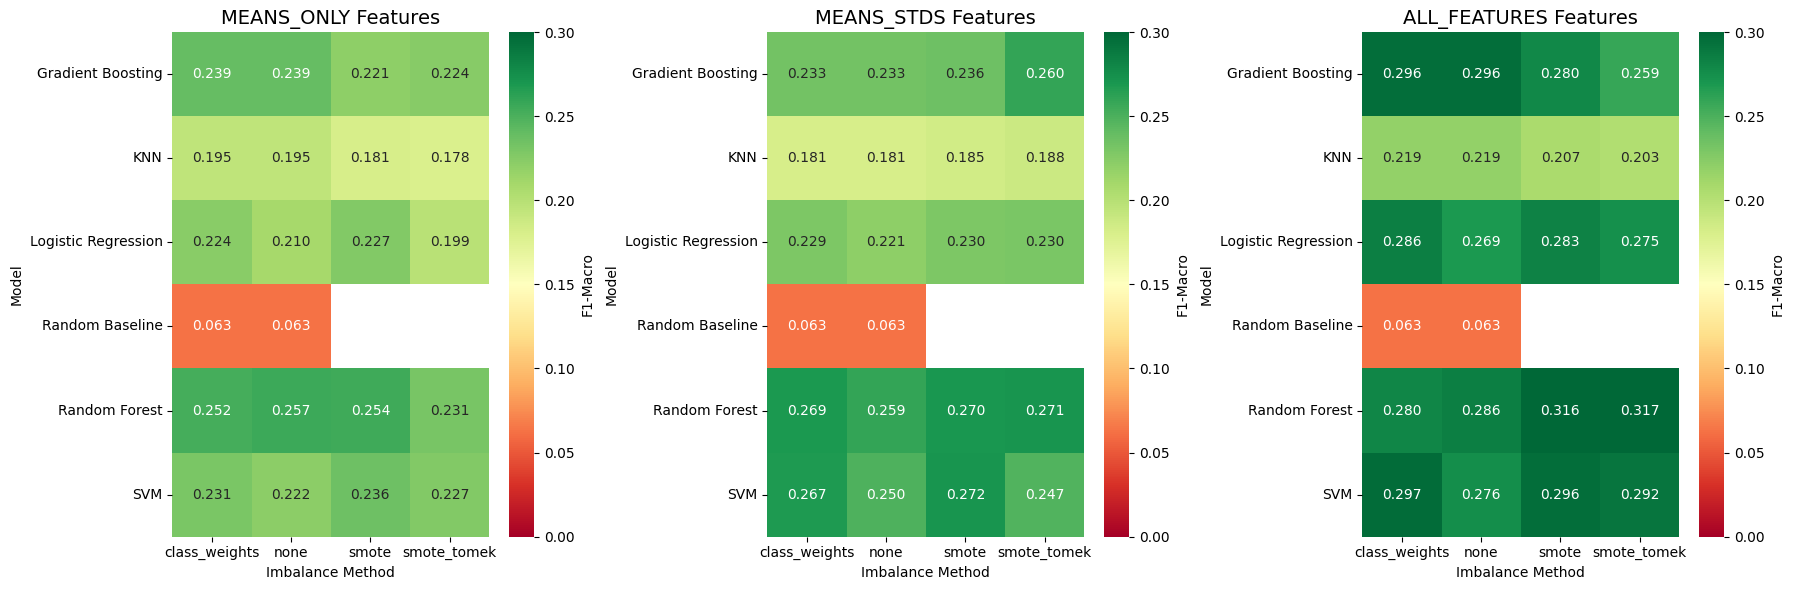

  Saved: /content/drive/MyDrive/mbti-tune/results/feature_set_comparison.png


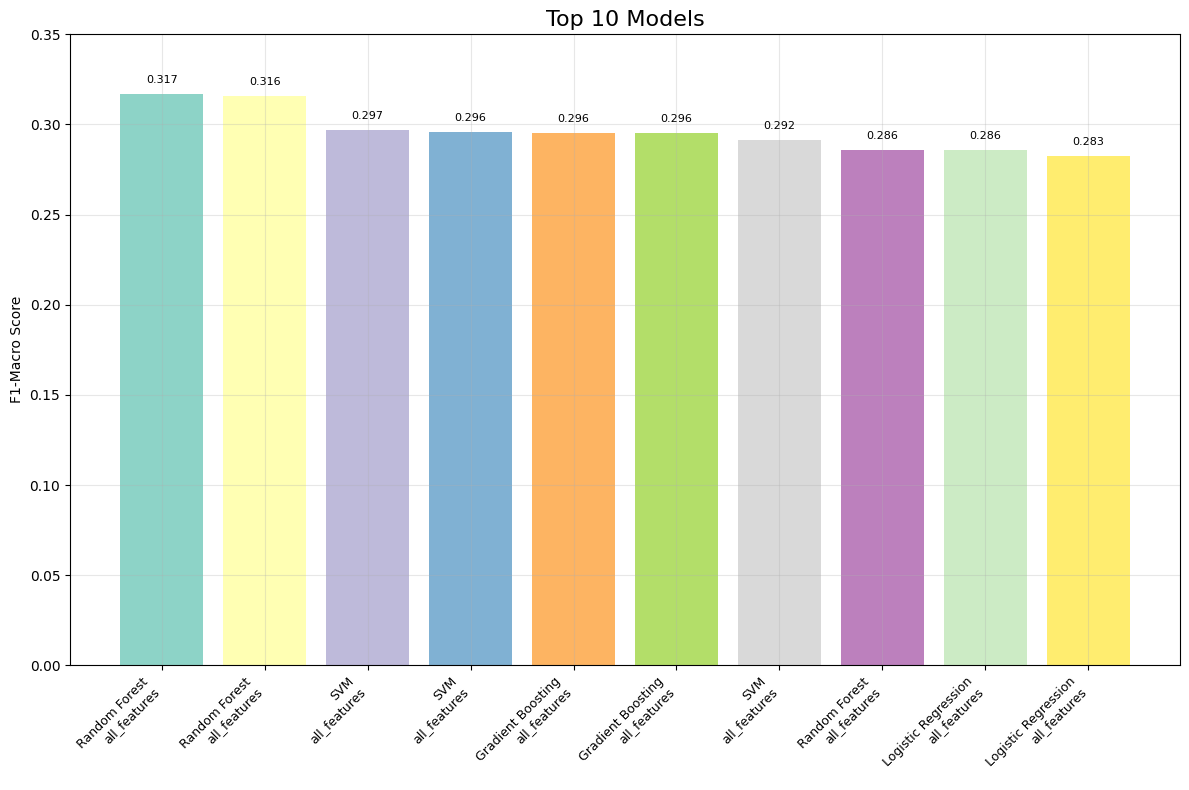

  Saved: /content/drive/MyDrive/mbti-tune/results/top_models.png


In [9]:
# ============================================
# 8. VISUALIZATIONS
# ============================================

print("\n" + "="*50)
print("8. CREATING VISUALIZATIONS")
print("="*50)

# 8a. Performance comparison by feature set
fig, axes = plt.subplots(1, 3, figsize=(18, 6))

for idx, set_name in enumerate(FEATURE_SETS.keys()):
    ax = axes[idx]
    set_results = df_results[df_results['Feature_Set'] == set_name]

    # Pivot for heatmap
    pivot = set_results.pivot(index='Model', columns='Imbalance_Method', values='F1_Macro')

    sns.heatmap(pivot, annot=True, fmt='.3f', cmap='RdYlGn',
                center=0.15, vmin=0, vmax=0.3, ax=ax,
                cbar_kws={'label': 'F1-Macro'})
    ax.set_title(f'{set_name.upper()} Features', fontsize=14)
    ax.set_xlabel('Imbalance Method')
    ax.set_ylabel('Model')

plt.tight_layout()
# plt.savefig(f'{RESULTS_PATH}/feature_set_comparison.png', dpi=150)
plt.show()
print(f"  Saved: {RESULTS_PATH}/feature_set_comparison.png")

# 8b. Best models comparison
fig, ax = plt.subplots(figsize=(12, 8))

# Get top 10 models
top10 = df_results.nlargest(10, 'F1_Macro')
x_pos = np.arange(len(top10))
bars = ax.bar(x_pos, top10['F1_Macro'],
              color=plt.cm.Set3(np.linspace(0, 1, len(top10))))

ax.set_xticks(x_pos)
ax.set_xticklabels([f"{row['Model']}\n{row['Feature_Set']}" for _, row in top10.iterrows()],
                   rotation=45, ha='right', fontsize=9)
ax.set_ylabel('F1-Macro Score')
ax.set_title('Top 10 Models', fontsize=16)
ax.grid(True, alpha=0.3)
ax.set_ylim([0, 0.35])

# Add value labels
for bar, val in zip(bars, top10['F1_Macro']):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.005,
            f'{val:.3f}', ha='center', va='bottom', fontsize=8)

plt.tight_layout()
# plt.savefig(f'{RESULTS_PATH}/top_models.png', dpi=150)
plt.show()
print(f"  Saved: {RESULTS_PATH}/top_models.png")


9. BEST MODEL ANALYSIS
Best Model: all_features_smote_tomek_Random Forest
Accuracy: 0.337
F1-Macro: 0.317
F1-Weighted: 0.330

Classification Report (Best Model):
              precision  recall  f1-score  support
ENFJ              0.385   0.167     0.233   60.000
ENFP              0.375   0.393     0.384   61.000
ENTJ              0.417   0.574     0.483   61.000
ENTP              0.540   0.443     0.486   61.000
ESFJ              0.150   0.130     0.140   23.000
ESFP              0.320   0.348     0.333   46.000
ESTJ              0.292   0.292     0.292   24.000
ESTP              0.300   0.393     0.340   61.000
INFJ              0.323   0.328     0.325   61.000
INFP              0.354   0.288     0.318   59.000
INTJ              0.271   0.258     0.264   62.000
INTP              0.386   0.533     0.448   60.000
ISFJ              0.257   0.409     0.316   44.000
ISFP              0.472   0.288     0.358   59.000
ISTJ              0.152   0.128     0.139   39.000
ISTP              0.2

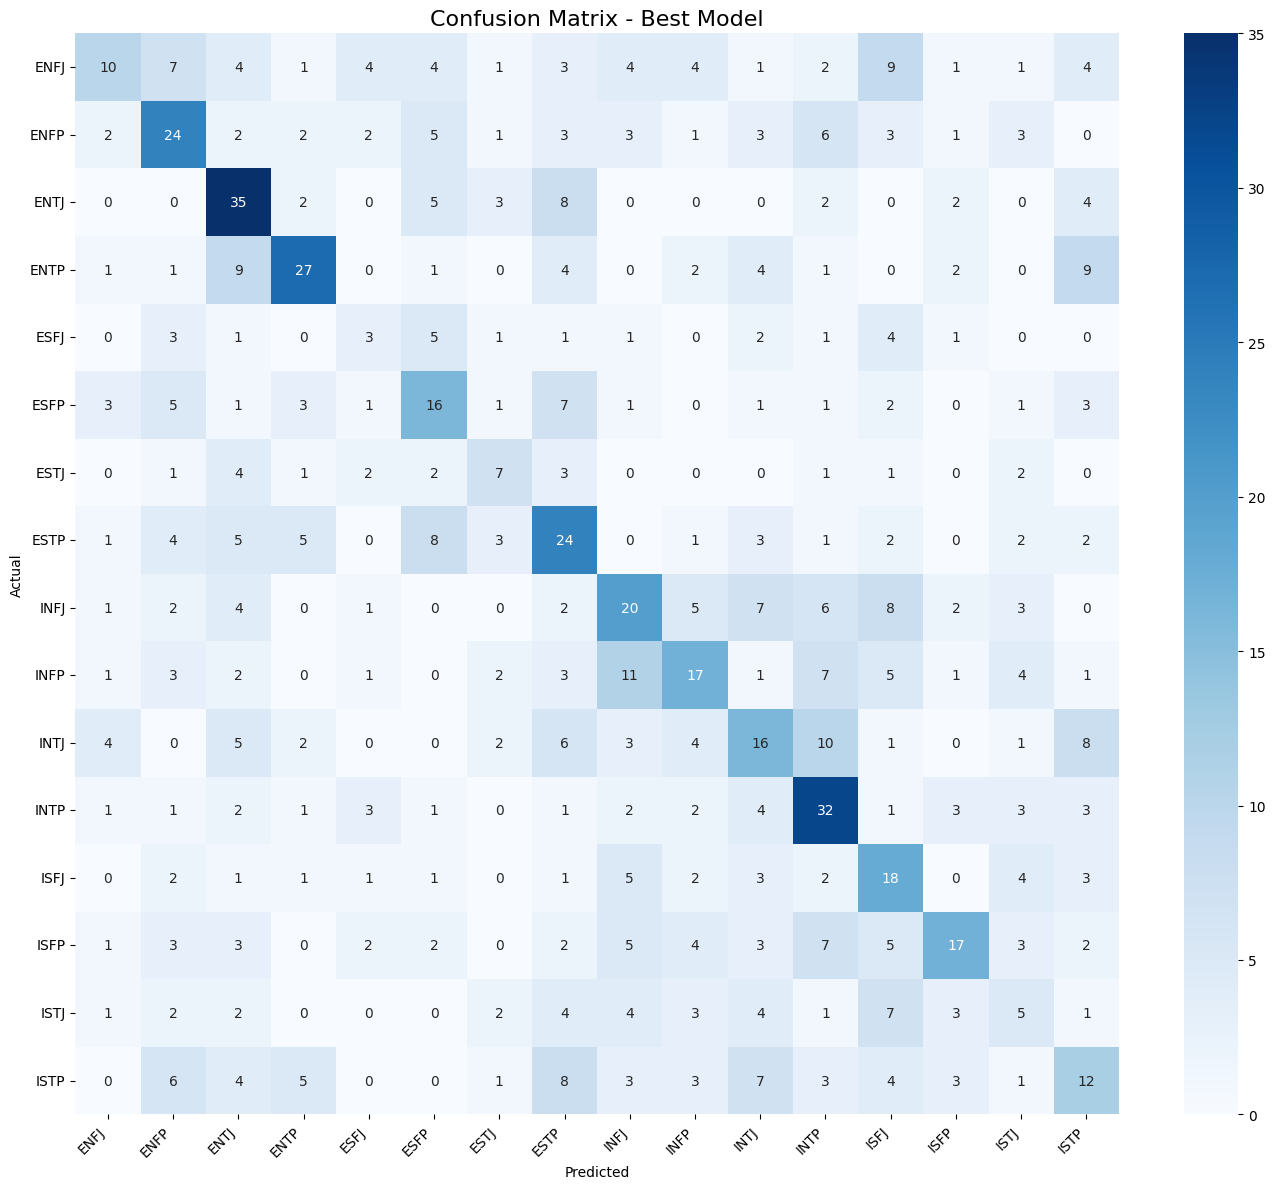

  Saved: /content/drive/MyDrive/mbti-tune/results/best_model_confusion_matrix.png


In [10]:
# ============================================
# 9. BEST MODEL ANALYSIS
# ============================================

print("\n" + "="*50)
print("9. BEST MODEL ANALYSIS")
print("="*50)

# Get best model
best_key = f"{best_row['Feature_Set']}_{best_row['Imbalance_Method']}_{best_row['Model']}"
best_results = all_results[best_key]

print(f"Best Model: {best_key}")
print(f"Accuracy: {best_results['accuracy']:.3f}")
print(f"F1-Macro: {best_results['f1_macro']:.3f}")
print(f"F1-Weighted: {best_results['f1_weighted']:.3f}")

# Get test data
set_name = best_row['Feature_Set']
y_test = splits[set_name]['y_test']

# Classification report
if 'y_pred' in best_results:
    report = classification_report(y_test, best_results['y_pred'],
                                   output_dict=True, zero_division=0)
    df_report = pd.DataFrame(report).transpose()
    df_report.to_csv(f'{RESULTS_PATH}/best_model_report.csv')

    print("\nClassification Report (Best Model):")
    print(df_report.round(3))

    # Confusion matrix
    cm = confusion_matrix(y_test, best_results['y_pred'])
    plt.figure(figsize=(14, 12))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=np.unique(y_test),
                yticklabels=np.unique(y_test))
    plt.title(f'Confusion Matrix - Best Model', fontsize=16)
    plt.xlabel('Predicted')
    plt.ylabel('Actual')
    plt.xticks(rotation=45, ha='right')
    plt.yticks(rotation=0)
    plt.tight_layout()
    # plt.savefig(f'{RESULTS_PATH}/best_model_confusion_matrix.png', dpi=150)
    plt.show()
    print(f"  Saved: {RESULTS_PATH}/best_model_confusion_matrix.png")


In [11]:
# ============================================
# 10. SAVE RESULTS
# ============================================

print("\n" + "="*50)
print("10. SAVING RESULTS")
print("="*50)

# Save comparison results
df_results.to_csv(f'{RESULTS_PATH}/all_model_comparison.csv', index=False)

# Save feature importance if best model is tree-based
if 'Random Forest' in best_key or 'Gradient Boosting' in best_key:
    model = best_results['model_obj']
    if hasattr(model, 'feature_importances_'):
        feature_importance = pd.DataFrame({
            'feature': FEATURE_SETS[set_name],
            'importance': model.feature_importances_
        }).sort_values('importance', ascending=False)
        feature_importance.to_csv(f'{RESULTS_PATH}/feature_importance.csv', index=False)
        print("\nTop 10 Most Important Features:")
        print(feature_importance.head(10).to_string(index=False))



10. SAVING RESULTS

Top 10 Most Important Features:
               feature  importance
          valence_mean    0.038914
     acousticness_mean    0.035036
      speechiness_mean    0.034432
           energy_mean    0.033167
     danceability_mean    0.032259
    acousticness_stdev    0.031924
         loudness_mean    0.030425
instrumentalness_stdev    0.030102
    danceability_stdev    0.030033
         valence_stdev    0.029972


In [13]:
# ============================================
# 11. FINAL SUMMARY
# ============================================

print("\n" + "="*80)
print("CLASSIFIER COMPLETE!")
print("="*80)

print(f"""
FINAL SUMMARY:
==============

BEST OVERALL MODEL:
  Feature Set:     {best_row['Feature_Set']}
  Imbalance Method: {best_row['Imbalance_Method']}
  Model:           {best_row['Model']}
  Accuracy:        {best_row['Accuracy']:.3f} ({best_row['Accuracy']*100:.1f}%)
  F1-Macro:        {best_row['F1_Macro']:.3f}
  F1-Weighted:     {best_row['F1_Weighted']:.3f}

PERFORMANCE BY FEATURE SET (Average F1-Macro):
""")

for set_name in FEATURE_SETS.keys():
    avg_f1 = df_results[df_results['Feature_Set'] == set_name]['F1_Macro'].mean()
    print(f"  {set_name}: {avg_f1:.3f}")

print(f"""
PERFORMANCE BY IMBALANCE METHOD (Average F1-Macro):""")
for method in df_results['Imbalance_Method'].unique():
    avg_f1 = df_results[df_results['Imbalance_Method'] == method]['F1_Macro'].mean()
    print(f"  {method}: {avg_f1:.3f}")

print(f"""
PERFORMANCE BY MODEL (Average F1-Macro):""")
for model in df_results['Model'].unique():
    if model != 'Random Baseline':
        avg_f1 = df_results[df_results['Model'] == model]['F1_Macro'].mean()
        print(f"  {model}: {avg_f1:.3f}")

print(f"""
FEATURES USED:
  Total features: {len(FEATURE_SETS[set_name])}
  Feature categories: Means, Standard Deviations, Key Counts

IMBALANCE HANDLING:
  - Class Weights: 
  - SMOTE: 
  - SMOTE+Tomek: 
  - Combined methods tested

SAVED FILES:
  {RESULTS_PATH}/feature_set_comparison.png
  {RESULTS_PATH}/top_models.png
  {RESULTS_PATH}/best_model_confusion_matrix.png
   {RESULTS_PATH}/all_model_comparison.csv
   {RESULTS_PATH}/best_model_report.csv
   {RESULTS_PATH}/feature_importance.csv (if applicable)

IMPROVEMENTS OVER PREVIOUS:
  - 10 features → {len(FEATURE_SETS[set_name])} features ({(len(FEATURE_SETS[set_name])-10)/10*100:.0f}% more)
  - Added statistics (stdev, key counts)
  - Multiple imbalance methods tested
  - More models compared (Gradient Boosting, SVM, KNN)
""")

print("="*80)
print("CLASSIFIER IMPLEMENTATION COMPLETE!")
print("="*80)


CLASSIFIER COMPLETE!

FINAL SUMMARY:

BEST OVERALL MODEL:
  Feature Set:     all_features
  Imbalance Method: smote_tomek
  Model:           Random Forest
  Accuracy:        0.337 (33.7%)
  F1-Macro:        0.317
  F1-Weighted:     0.330

PERFORMANCE BY FEATURE SET (Average F1-Macro):

  means_only: 0.208
  means_stds: 0.220
  all_features: 0.253

PERFORMANCE BY IMBALANCE METHOD (Average F1-Macro):
  none: 0.211
  class_weights: 0.216
  smote: 0.246
  smote_tomek: 0.240

PERFORMANCE BY MODEL (Average F1-Macro):
  Logistic Regression: 0.240
  Random Forest: 0.272
  Gradient Boosting: 0.251
  SVM: 0.259
  KNN: 0.194

FEATURES USED:
  Total features: 44
  Feature categories: Means, Standard Deviations, Key Counts

IMBALANCE HANDLING:
  - Class Weights: 
  - SMOTE: 
  - SMOTE+Tomek: 
  - Combined methods tested

SAVED FILES:
  /content/drive/MyDrive/mbti-tune/results/feature_set_comparison.png
  /content/drive/MyDrive/mbti-tune/results/top_models.png
  /content/drive/MyDrive/mbti-tune/res